In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.colors import FuncNorm
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
from ellipse import LsqEllipse

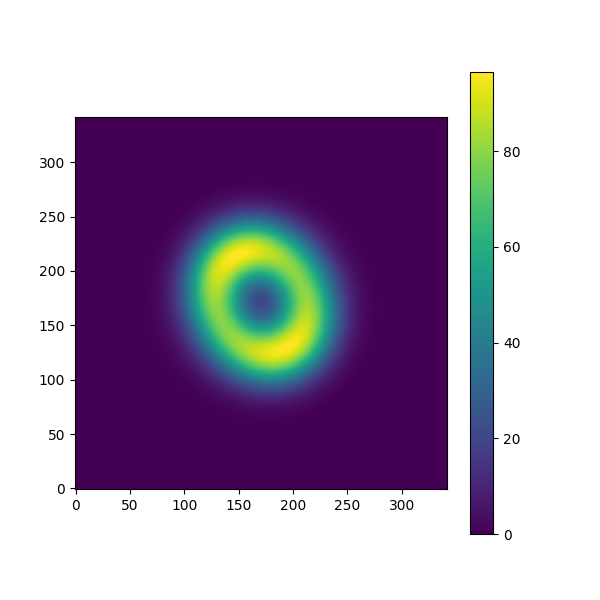

In [2]:
from astropy.io import fits
from scipy.ndimage import rotate, gaussian_filter
import os

PA = 28.4
i = 36.4

def inclined_disk(inc=39.22, r_peak=50.0, sigma_r=15.0, t0=5.0, pa=26.35, 
                         dt=0.2, tmax_factor=4.0, smoothing=1.0):
    """
    Crea un'immagine di un disco inclinato con:
    - Profilo radiale GAUSSIANO (picco a r_peak, dispersione sigma_r)
    - Profilo verticale esponenziale (spessore t0)
    
    Parametri:
    r_peak : float
        Raggio dove l'intensità è massima
    sigma_r : float
        Dispersione radiale della gaussiana (controlla la "larghezza")
    """
    # Conversione angoli in radianti
    inc_rad = np.radians(inc)
    cosinc = np.cos(inc_rad)
    sininc = np.sin(inc_rad)
    
    # Dimensioni dell'immagine
    n = int((r_peak + 3*sigma_r) * 1.1)  # Abbastanza grande da contenere la gaussiana
    tmax = tmax_factor * t0
    nt = int(tmax / dt)
    
    # Creazione griglia estesa
    extended_size = int(2 * np.sqrt(2) * n)
    img = np.zeros((extended_size, extended_size))
    center = extended_size // 2
    i_arr = np.arange(extended_size) - center
    j_arr = np.arange(extended_size) - center
    
    # Creazione disco con profilo radiale gaussiano
    for i in range(extended_size):
        for j in range(extended_size):
            r = np.sqrt(i_arr[i]**2 + (j_arr[j]/cosinc)**2)  # Distanza radiale (ellittica per inclinazione)
            # Profilo gaussiano radiale
            I_r = np.exp(-(r - r_peak)**2 / (2 * sigma_r**2))

            
            if I_r > 0.01:  # Taglio per efficienza
                for k in range(-nt, nt + 1):
                    z = dt * k
                    w = np.exp(-abs(z / t0)) * I_r  # Combina profilo radiale e verticale
                    xp = i_arr[i]
                    yp = j_arr[j] + z  # Proiezione verticale
                    x_idx = int(round(xp + center))
                    y_idx = int(round(yp + center))
                    if 0 <= x_idx < extended_size and 0 <= y_idx < extended_size:
                        img[x_idx, y_idx] += w
    
    # Rotazione per allineare l'asse maggiore al PA
    img_rot = rotate(img, -pa, reshape=False, order=1, mode='constant')
    
    # Smoothing finale
    if smoothing > 0:
        img_rot = gaussian_filter(img_rot, sigma=smoothing)
    
    return img_rot

img = inclined_disk(
    inc=i,
    r_peak=50.0,   # Raggio di picco della gaussiana
    sigma_r=20.0,   # Larghezza della gaussiana
    t0=50*0.2,
    pa=PA
)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='viridis', origin='lower')
plt.colorbar()
plt.show()

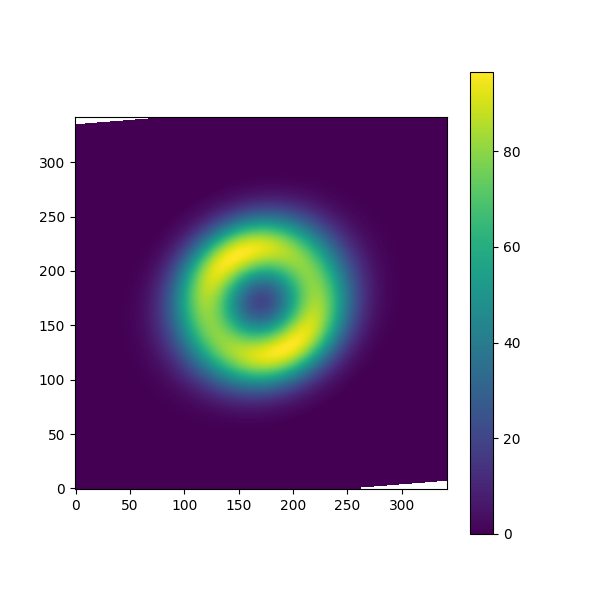

In [3]:
from scipy.ndimage import map_coordinates

def deproject_disk(image, inc_deg, pa_astro_deg, order=3):
    """
    Correctly deprojects images with NaN values:
    - Stretches perpendicular to PA by 1/cos(i)
    - Preserves PA axis length
    - Maintains original dimensions
    - Handles existing NaN values properly
    """
    if inc_deg == 0:
        return image.copy()

    # Create mask of non-NaN pixels
    mask = np.isfinite(image)
    image_no_nan = np.where(mask, image, 0)

    ny, nx = image.shape
    center = np.array([(ny-1)/2, (nx-1)/2])
    y, x = np.indices((ny, nx))
    coords = np.vstack([y.ravel() - center[0], x.ravel() - center[1]])

    # Convert PA (North-to-West) to math convention
    theta = np.radians(pa_astro_deg)
    stretch = 1 / np.cos(np.radians(inc_deg))

    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    rot_matrix = np.array([[c, -s], [s, c]])

    # Transform coordinates
    aligned = rot_matrix @ coords
    aligned[1] /= stretch  # Correct stretching direction
    final_coords = rot_matrix.T @ aligned
    final_coords += center[:, None]

    # Interpolate image and mask separately
    deprojected = map_coordinates(image_no_nan, final_coords, 
                                order=order, mode='constant', cval=np.nan)
    mask_deprojected = map_coordinates(mask.astype(float), final_coords,
                                    order=0, mode='constant', cval=0)

    # Combine results
    result = deprojected.reshape((ny, nx))
    result[mask_deprojected.reshape((ny, nx)) < 0.5] = np.nan
    
    return result

img_d = deproject_disk(img, i, PA, order=3)

plt.figure(figsize=(6,6))
plt.imshow(img_d, cmap='viridis', origin='lower')
plt.colorbar()
plt.show()

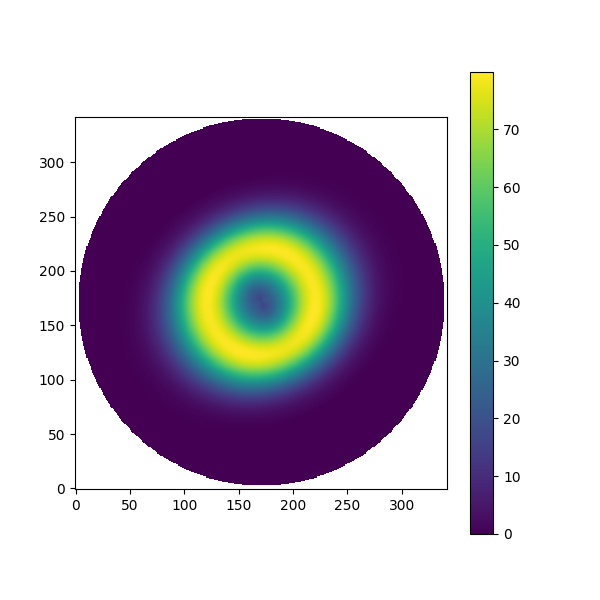

In [4]:
def correct_disk_flux(image, inc_deg, pa_deg, center_offset_x=0, center_offset_y=0, mask_edges=True):

    # Convert angles to radians
    inc = np.radians(inc_deg)
    pa = np.radians(pa_deg)
    
    # Create grid of pixel coordinates (relative to disk center)
    ny, nx = image.shape
    x = np.arange(nx) - (nx // 2 + center_offset_x)
    y = np.arange(ny) - (ny // 2 + center_offset_y)
    xx, yy = np.meshgrid(x, y)
    
    # Compute azimuthal angles
    phi = np.arctan2(-xx, yy)  # arctan2(-x, y) anti-clockwise sense
    
    # Compute correction factor
    correction = np.sqrt(np.cos(inc)**2 + np.sin(inc)**2 * np.sin(phi - pa)**2)
    
    # Apply correction
    corrected_image = image * correction
    
    # Optional: Mask edges to avoid artifacts
    if mask_edges:
        r = np.sqrt(xx**2 + yy**2)
        max_r = min(nx, ny) // 2 - 2  # Adjust buffer as needed
        corrected_image[r > max_r] = np.nan
    
    return corrected_image

img_d_corr = correct_disk_flux(img_d, i, PA, mask_edges=True)

plt.figure(figsize=(6,6))
plt.imshow(img_d_corr, cmap='viridis', origin='lower')
plt.colorbar()
plt.show()